# Regularización en Redes Neuronales con TensorFlow

### Tipos de regularización.

- **L1 (Lasso)**: Penaliza la suma de los valores absolutos de los pesos. Promueve **sparsity**, realiza selección automática de variables y mejora la interpretabilidad del modelo

- **L2 (Ridge)**: Penaliza la suma de los cuadrados de los pesos. Reduce la varianza, estabiliza el entrenamiento y mitiga los efectos de la colinealidad al distribuir los pesos.

- **Elastic Net**: Combinación de **L1** y **L2**. Mantiene sparsity mientras conserva estabilidad númerica, siendo util cuando existen variables altamente correlacionadas

## Librerias

In [13]:
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

## Cargamos Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

4422102/4422102 [==============================] - 0s 0us/step


## Modelo baseline

In [4]:
def build_baseline():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [5]:
baseline = build_baseline()
history_baseline = baseline.fit(x_train, y_train, epochs=5, validation_split=0.2)

2026-01-09 11:25:04.814391: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-09 11:25:04.814437: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-09 11:25:04.814451: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-01-09 11:25:04.814695: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-09 11:25:04.815047: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/5


2026-01-09 11:25:05.519223: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1500/1500 [==============================] - 11s 6ms/step - loss: 0.6625 - accuracy: 0.7806 - val_loss: 0.8151 - val_accuracy: 0.7834
Epoch 2/5
1500/1500 [==============================] - 10s 7ms/step - loss: 1.3857 - accuracy: 0.7561 - val_loss: 2.2438 - val_accuracy: 0.7188
Epoch 3/5
1500/1500 [==============================] - 9s 6ms/step - loss: 3.1524 - accuracy: 0.7430 - val_loss: 2.9807 - val_accuracy: 0.7592
Epoch 4/5
1500/1500 [==============================] - 9s 6ms/step - loss: 5.7197 - accuracy: 0.7367 - val_loss: 11.0874 - val_accuracy: 0.6744
Epoch 5/5
1500/1500 [==============================] - 9s 6ms/step - loss: 8.9038 - accuracy: 0.7357 - val_loss: 7.4504 - val_accuracy: 0.7498


## Modelo con L2

In [6]:
l2 = tf.keras.regularizers.l2(0.001)

def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation='relu', kernel_regularizer=l2),
        layers.Dense(128, activation='relu', kernel_regularizer=l2),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [8]:
model_l2 = build_l2_model()
history_l2 = model_l2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 [==============================] - 24s 16ms/step - loss: 0.9266 - accuracy: 0.7834 - val_loss: 0.9505 - val_accuracy: 0.8139
Epoch 2/10
1500/1500 [==============================] - 23s 16ms/step - loss: 1.6547 - accuracy: 0.7577 - val_loss: 2.9331 - val_accuracy: 0.7487
Epoch 3/10
1500/1500 [==============================] - 24s 16ms/step - loss: 4.1167 - accuracy: 0.7340 - val_loss: 6.0315 - val_accuracy: 0.7422
Epoch 4/10
1500/1500 [==============================] - 23s 15ms/step - loss: 8.2779 - accuracy: 0.7203 - val_loss: 10.0408 - val_accuracy: 0.7613
Epoch 5/10
1500/1500 [==============================] - 23s 15ms/step - loss: 12.9786 - accuracy: 0.7203 - val_loss: 15.1189 - val_accuracy: 0.6754
Epoch 6/10
1500/1500 [==============================] - 21s 14ms/step - loss: 19.8370 - accuracy: 0.7160 - val_loss: 21.0987 - val_accuracy: 0.7469
Epoch 7/10
1500/1500 [==============================] - 23s 15ms/step - loss: 27.1573 - accuracy: 0.7184 - val_loss: 28

## Modelo con L1

In [9]:
l1 = tf.keras.regularizers.l1(0.001)

def build_l1_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation='relu', kernel_regularizer=l1),
        layers.Dense(128, activation='relu', kernel_regularizer=l1),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [15]:
model_l1 = build_l1_model()
history_l1 = model_l1.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 [==============================] - 11s 7ms/step - loss: 1.8240 - accuracy: 0.7703 - val_loss: 0.8688 - val_accuracy: 0.8058
Epoch 2/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.8141 - accuracy: 0.8070 - val_loss: 0.8032 - val_accuracy: 0.7999
Epoch 3/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.7560 - accuracy: 0.8139 - val_loss: 0.7383 - val_accuracy: 0.8124
Epoch 4/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.7381 - accuracy: 0.8161 - val_loss: 0.7096 - val_accuracy: 0.8261
Epoch 5/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.7288 - accuracy: 0.8208 - val_loss: 0.7269 - val_accuracy: 0.8200
Epoch 6/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.7440 - accuracy: 0.8184 - val_loss: 0.7467 - val_accuracy: 0.8195
Epoch 7/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.7735 - accuracy: 0.8198 - val_loss: 0.9332 - val_ac

## Modelo con Elastic Net

In [10]:
elastic_net = tf.keras.regularizers.l1_l2(l1=0.001, l2=0.001)

def build_elastic_net_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation='relu', kernel_regularizer=elastic_net),
        layers.Dense(128, activation='relu', kernel_regularizer=elastic_net),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [11]:
model_elastic_net = build_elastic_net_model()
history_elastic_net = model_elastic_net.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 [==============================] - 24s 16ms/step - loss: 1.7669 - accuracy: 0.7679 - val_loss: 0.8856 - val_accuracy: 0.7937
Epoch 2/10
1500/1500 [==============================] - 23s 15ms/step - loss: 0.8069 - accuracy: 0.8077 - val_loss: 0.7795 - val_accuracy: 0.8058
Epoch 3/10
1500/1500 [==============================] - 24s 16ms/step - loss: 0.7422 - accuracy: 0.8153 - val_loss: 0.7255 - val_accuracy: 0.8213
Epoch 4/10
1500/1500 [==============================] - 23s 15ms/step - loss: 0.7170 - accuracy: 0.8164 - val_loss: 0.7039 - val_accuracy: 0.8201
Epoch 5/10
1500/1500 [==============================] - 23s 15ms/step - loss: 0.7037 - accuracy: 0.8195 - val_loss: 0.7002 - val_accuracy: 0.8243
Epoch 6/10
1500/1500 [==============================] - 23s 16ms/step - loss: 0.7126 - accuracy: 0.8203 - val_loss: 0.7053 - val_accuracy: 0.8276
Epoch 7/10
1500/1500 [==============================] - 23s 15ms/step - loss: 0.7456 - accuracy: 0.8185 - val_loss: 0.7844 -

# Comparación gráfica.

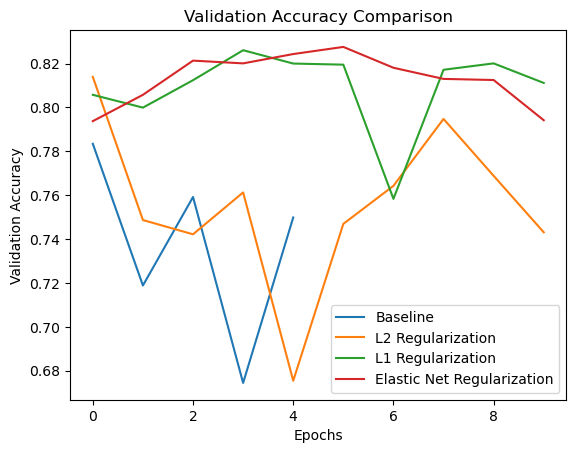

In [16]:
# Comparamos los diferentes modelos contra el modelo base
plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_l2.history['val_accuracy'], label='L2 Regularization')
plt.plot(history_l1.history['val_accuracy'], label='L1 Regularization')
plt.plot(history_elastic_net.history['val_accuracy'], label='Elastic Net Regularization')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()